# Workforce Exploratory Data Analysis

> **Historical Version 1 evidence only.** This notebook does not describe the temporal data used by the current model, policy, or dashboard. See [Notebook 37: Version 2 Exploratory Analysis](37_v2_exploratory_analysis.ipynb).


This notebook presents exploratory analysis of two related Version 1 populations:

1. The full 10,000-record synthetic workforce.
2. The 7,386-employee retention-modeling population observed on June 30, 2025 and followed through June 30, 2026.

The analysis is descriptive. Relationships should not be interpreted causally because Checkpoint 32 demonstrated that several patterns are hard-coded or generated after the termination outcome.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display


candidate_roots = [
    Path.cwd(),
    *Path.cwd().parents,
]

PROJECT_ROOT = next(
    path
    for path in candidate_roots
    if (
        path
        / "data"
        / "processed"
        / "eda"
    ).exists()
)

EDA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "eda"
)

metadata = pd.read_csv(
    EDA_DIR / "eda_metadata.csv"
)

target_balance = pd.read_csv(
    EDA_DIR / "target_balance.csv"
)

missingness = pd.read_csv(
    EDA_DIR / "missingness_summary.csv"
)

missingness_target = pd.read_csv(
    EDA_DIR
    / "missingness_target_association.csv"
)

numeric_associations = pd.read_csv(
    EDA_DIR
    / "numeric_target_associations.csv"
)

categorical_rates = pd.read_csv(
    EDA_DIR
    / "categorical_attrition_rates.csv"
)

binned_rates = pd.read_csv(
    EDA_DIR / "binned_attrition_rates.csv"
)

categorical_strength = pd.read_csv(
    EDA_DIR
    / "categorical_target_strength.csv"
)

high_correlations = pd.read_csv(
    EDA_DIR
    / "high_numeric_correlations.csv"
)

categorical_redundancy = pd.read_csv(
    EDA_DIR / "categorical_redundancy.csv"
)

print(f"EDA directory: {EDA_DIR}")

EDA directory: c:\Users\Yuchen Xu\Documents\workforce-intelligence-platform\data\processed\eda


In [2]:
display(Markdown("## Population and target"))
display(metadata)
display(target_balance)

display(Markdown("## Missing-data structure"))
display(
    missingness
    .loc[missingness["missing_count"].gt(0)]
)
display(missingness_target)

display(
    Markdown(
        "## Strongest numeric relationships "
        "with the target"
    )
)
display(numeric_associations.head(15))

display(
    Markdown(
        "## Department attrition rates"
    )
)
display(
    categorical_rates.loc[
        categorical_rates["feature"].eq(
            "hire_department_name"
        )
    ].sort_values(
        "attrition_rate",
        ascending=False,
    )
)

display(
    Markdown(
        "## Job-family attrition rates"
    )
)
display(
    categorical_rates.loc[
        categorical_rates["feature"].eq(
            "hire_job_family"
        )
    ].sort_values(
        "attrition_rate",
        ascending=False,
    )
)

display(
    Markdown(
        "## Feature redundancy"
    )
)
display(high_correlations)
display(categorical_redundancy)

## Population and target

,metric,value
0,Workforce records,10000
1,Modeling records,7386
2,Modeling columns,39
3,Unique employees in modeling data,7386
4,Snapshot dates,2025-06-30
5,Prediction end dates,2026-06-30
6,Overall attrition rate,0.084890


,target_value,record_count,target_label,record_share
0,0,6759,No attrition,0.91511
1,1,627,Attrition,0.08489


## Missing-data structure

,feature,missing_count,missing_rate
0,days_since_last_change_event,5542,0.750338
1,average_performance_rating,1805,0.244381
2,promotion_recommended,1805,0.244381
3,performance_rating,1805,0.244381
4,days_since_review,1805,0.244381
5,goal_completion,1805,0.244381
6,average_training_score,124,0.016789


...

## Job-family attrition rates

,feature,category,sample_size,attrition_cases,attrition_rate,baseline_attrition_rate,lift_vs_baseline
34,hire_job_family,Manufacturing,1018,104,0.102161,0.08489,1.203448
28,hire_job_family,Customer Support,578,58,0.100346,0.08489,1.182067
27,hire_job_family,Analytics,1288,117,0.090839,0.08489,1.070069
30,hire_job_family,Engineering,1665,147,0.088288,0.08489,1.040028
29,hire_job_family,Data Science,381,31,0.081365,0.08489,0.958470
31,hire_job_family,Finance,316,25,0.079114,0.08489,0.931954
35,hire_job_family,Sales,730,53,0.072603,0.08489,0.855253
36,hire_job_family,Supply Chain,900,64,0.071111,0.08489,0.837682
33,hire_job_family,Information Technology,217,12,0.055300,0.08489,0.651423
32,hire_job_family,Human Resources,293,16,0.054608,0.08489,0.643271


## Feature redundancy

,first_feature,second_feature,correlation,absolute_correlation
0,promotion_compensation_count,prior_promotion_events,1.000000,1.000000
1,days_since_compensation_change,days_since_review,1.000000,1.000000
2,tenure_years,compensation_record_count,0.975734,0.975734
3,initial_base_salary,base_salary,0.973190,0.973190
4,performance_rating,average_performance_rating,0.962114,0.962114
5,completed_training_programs,completed_training_hours,0.928179,0.928179
6,salary_growth_percent,compensation_record_count,0.907189,0.907189
7,hire_job_level,bonus_target,0.905153,0.905153
8,hire_job_level,initial_base_salary,0.897684,0.897684
9,tenure_years,salary_growth_percent,0.886930,0.886930


,first_feature,second_feature,corrected_cramers_v
0,hire_job_family,employment_type,0.889314
1,hire_department_name,hire_job_family,0.839305
2,hire_department_name,employment_type,0.730341
3,hire_job_family,hire_job_level,0.657837
4,hire_department_name,hire_region,0.000000


## Class Imbalance

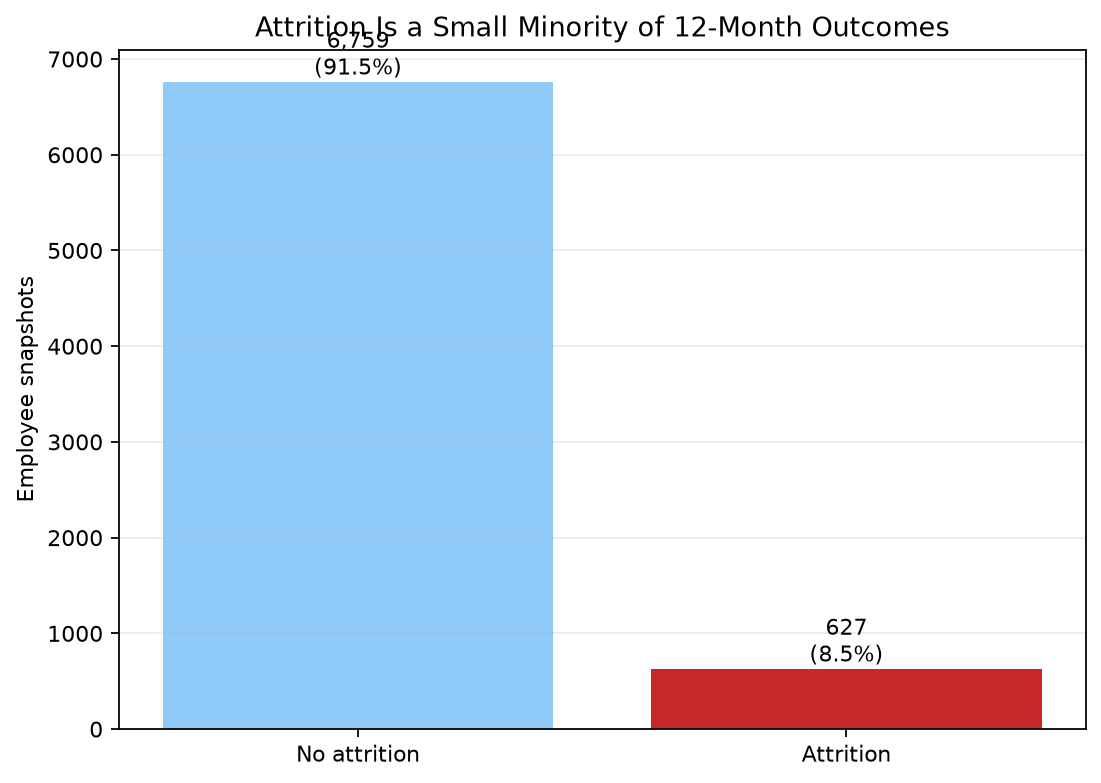

## Attrition By Department

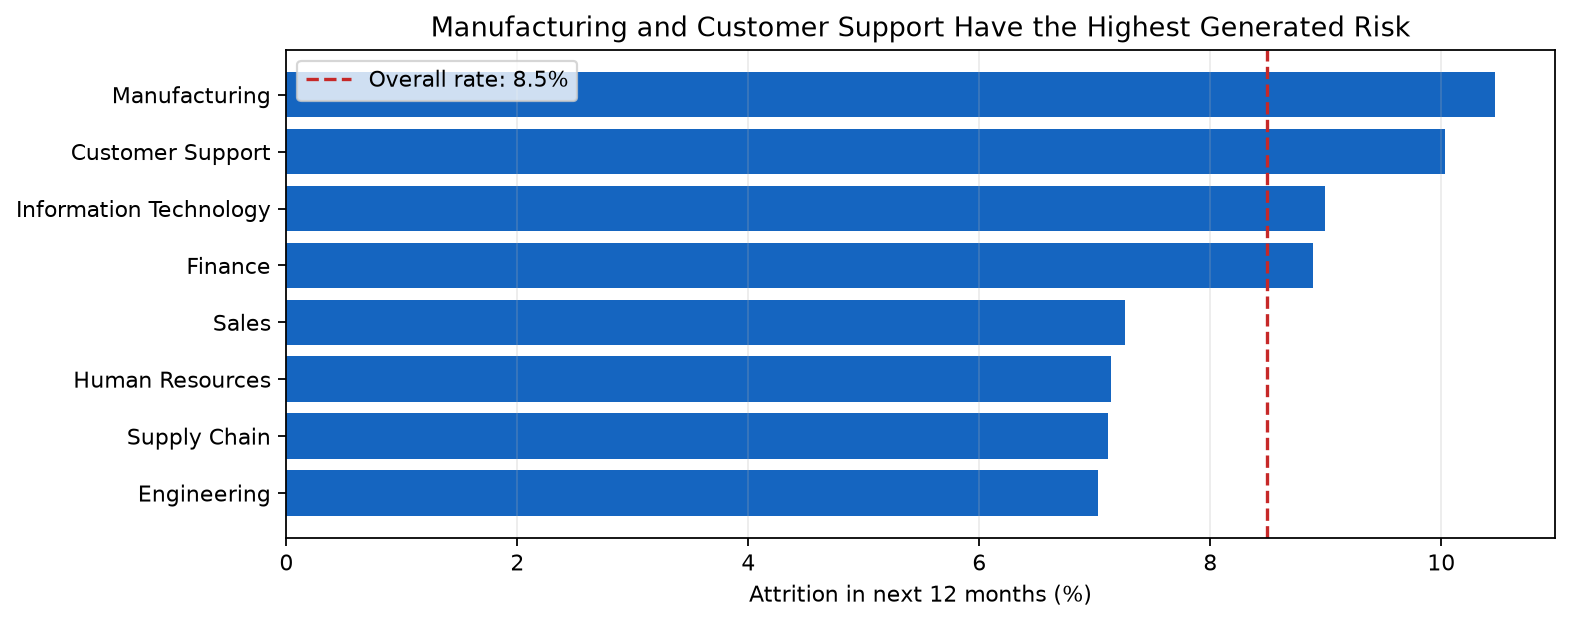

## Attrition By Job Family

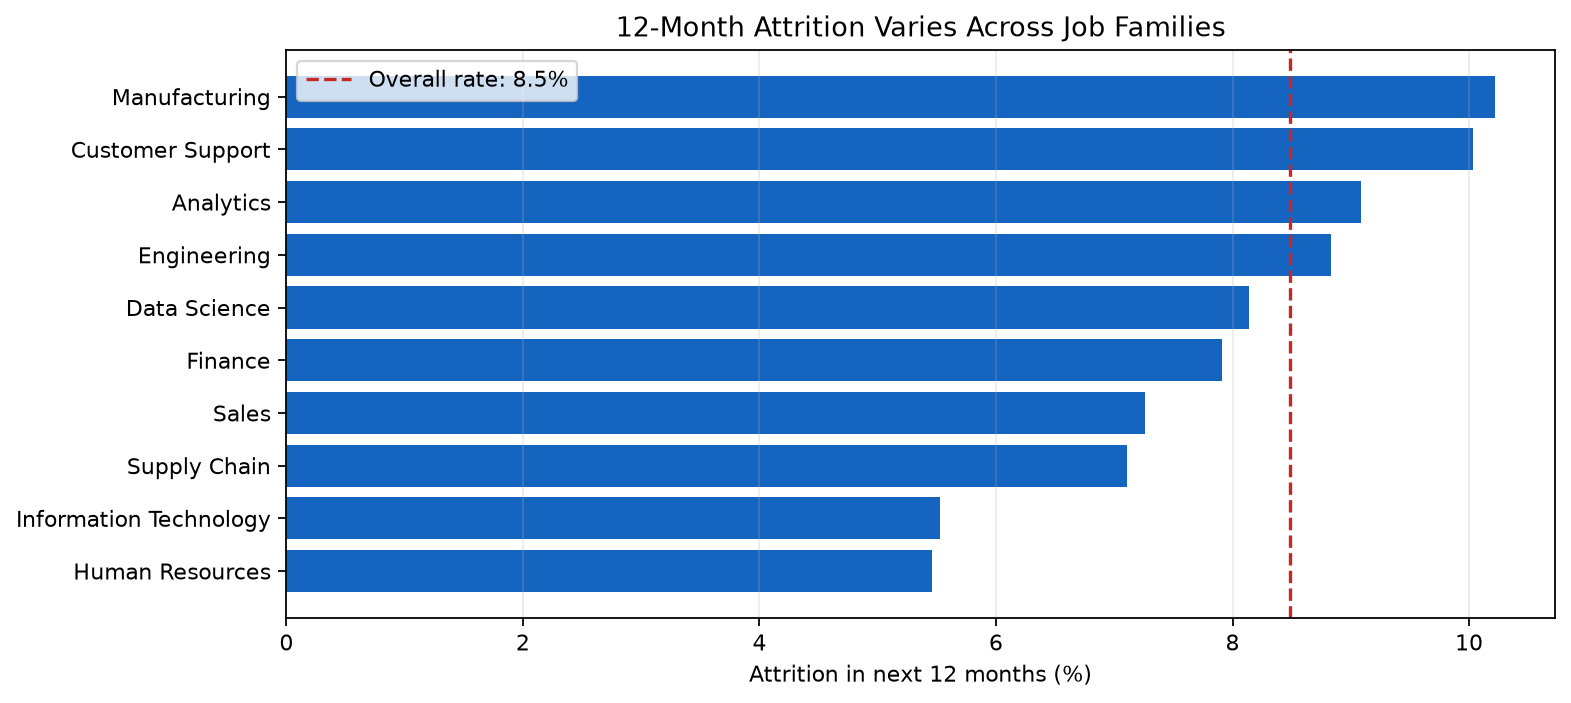

## Attrition By Tenure

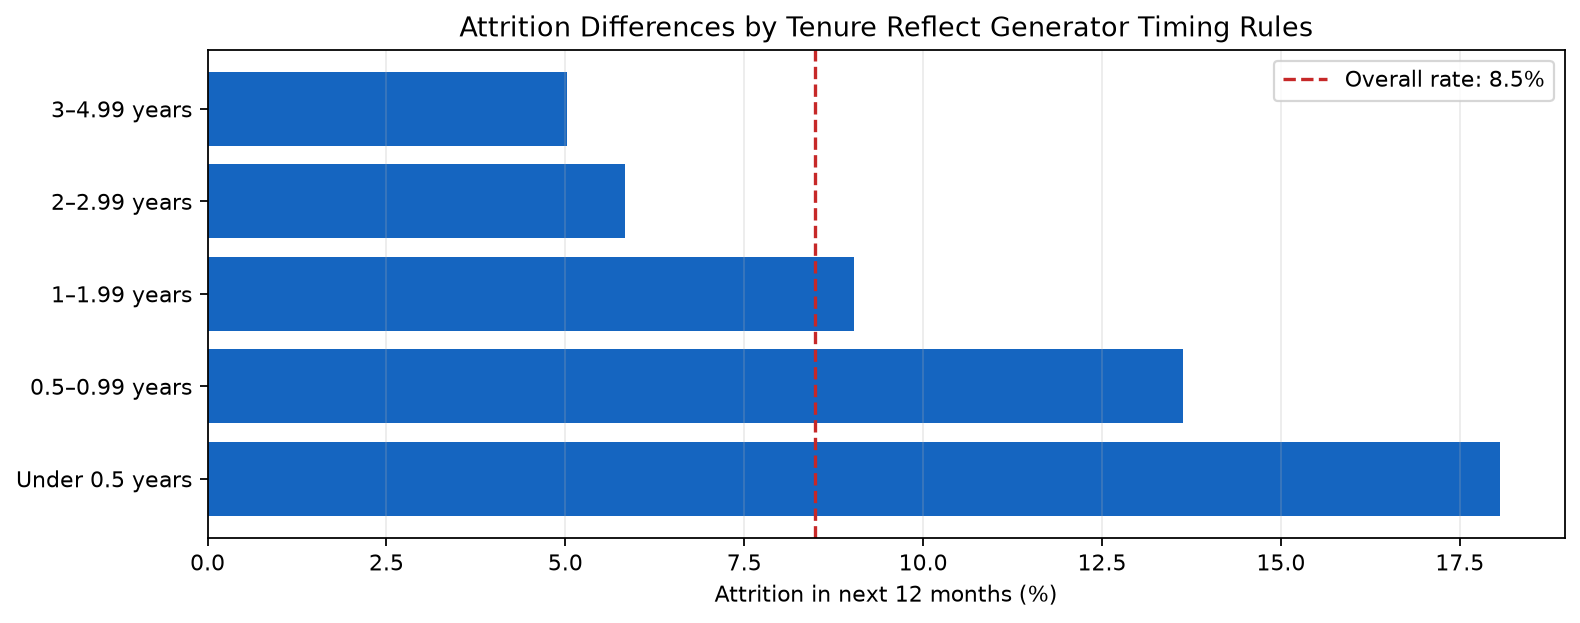

## Attrition By Performance

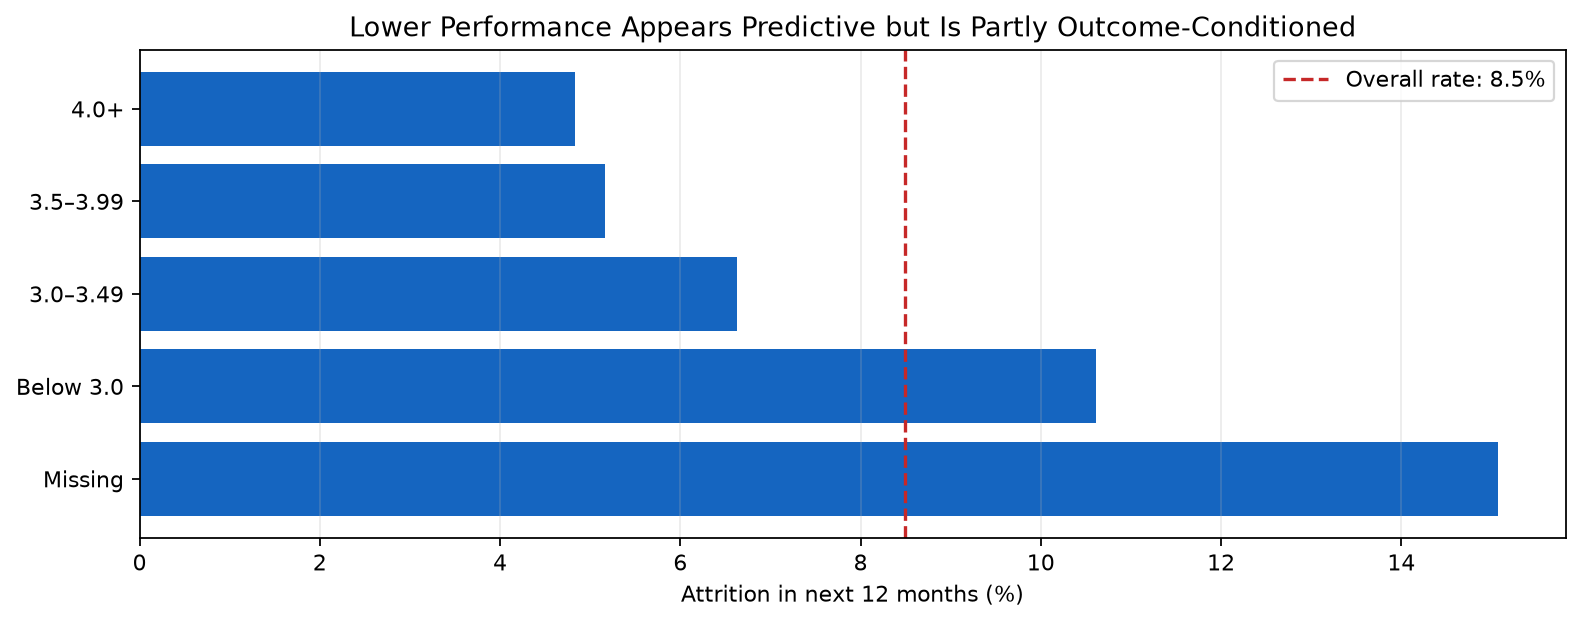

## Salary By Outcome

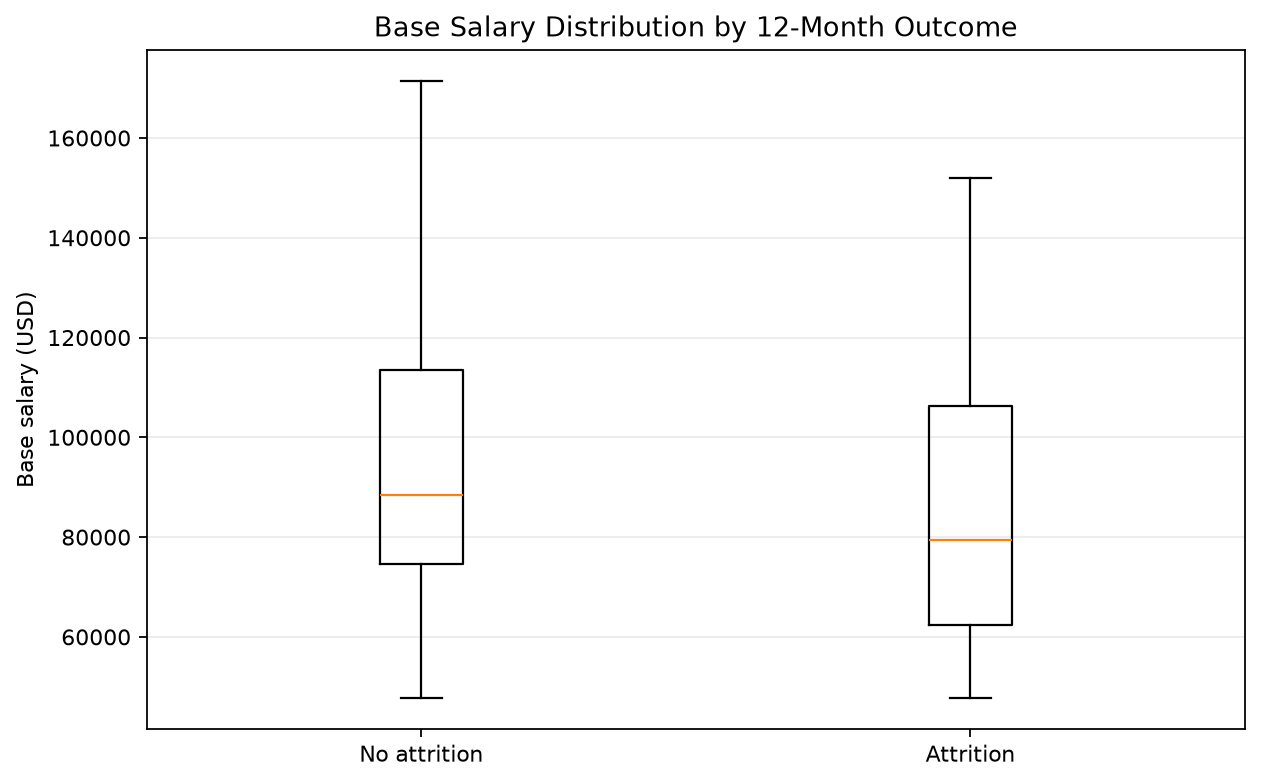

## Missingness

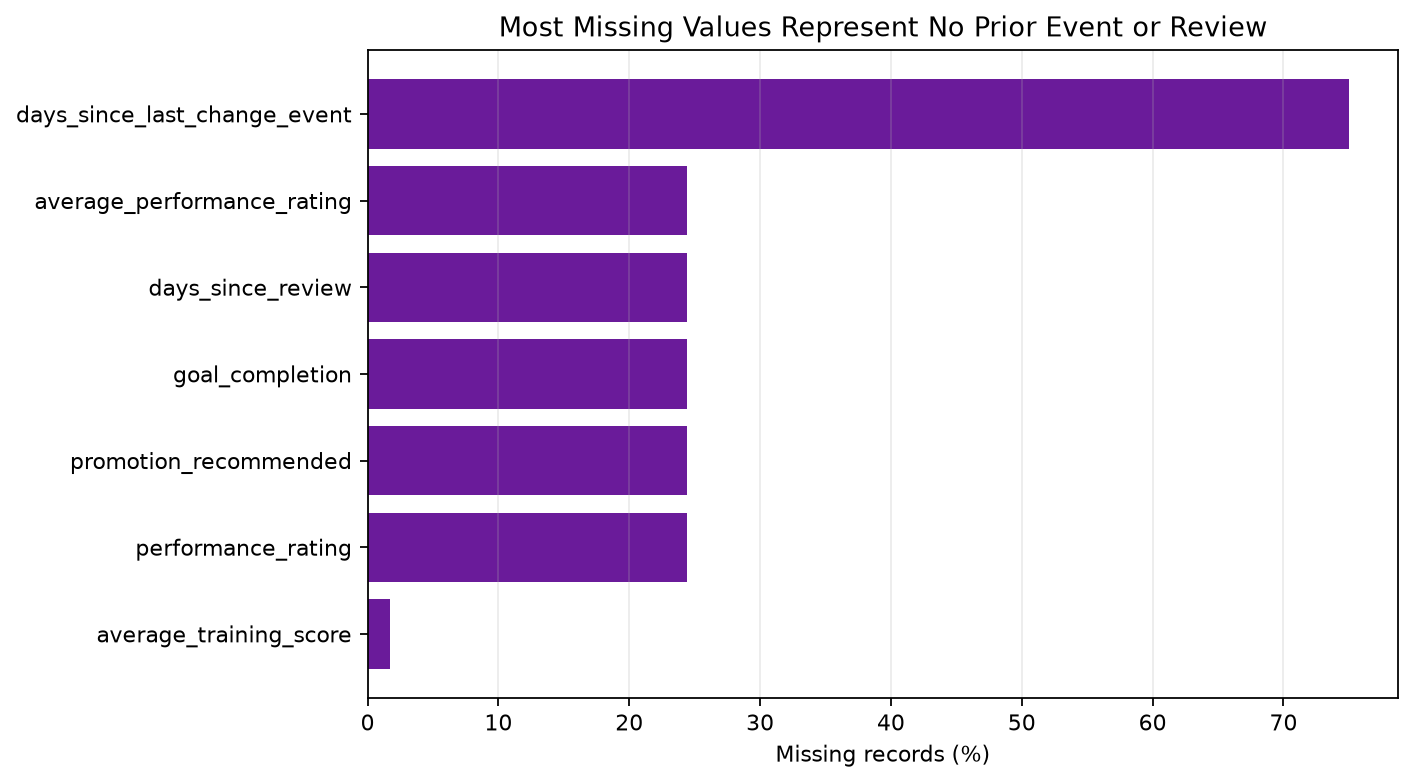

## Numeric Correlation

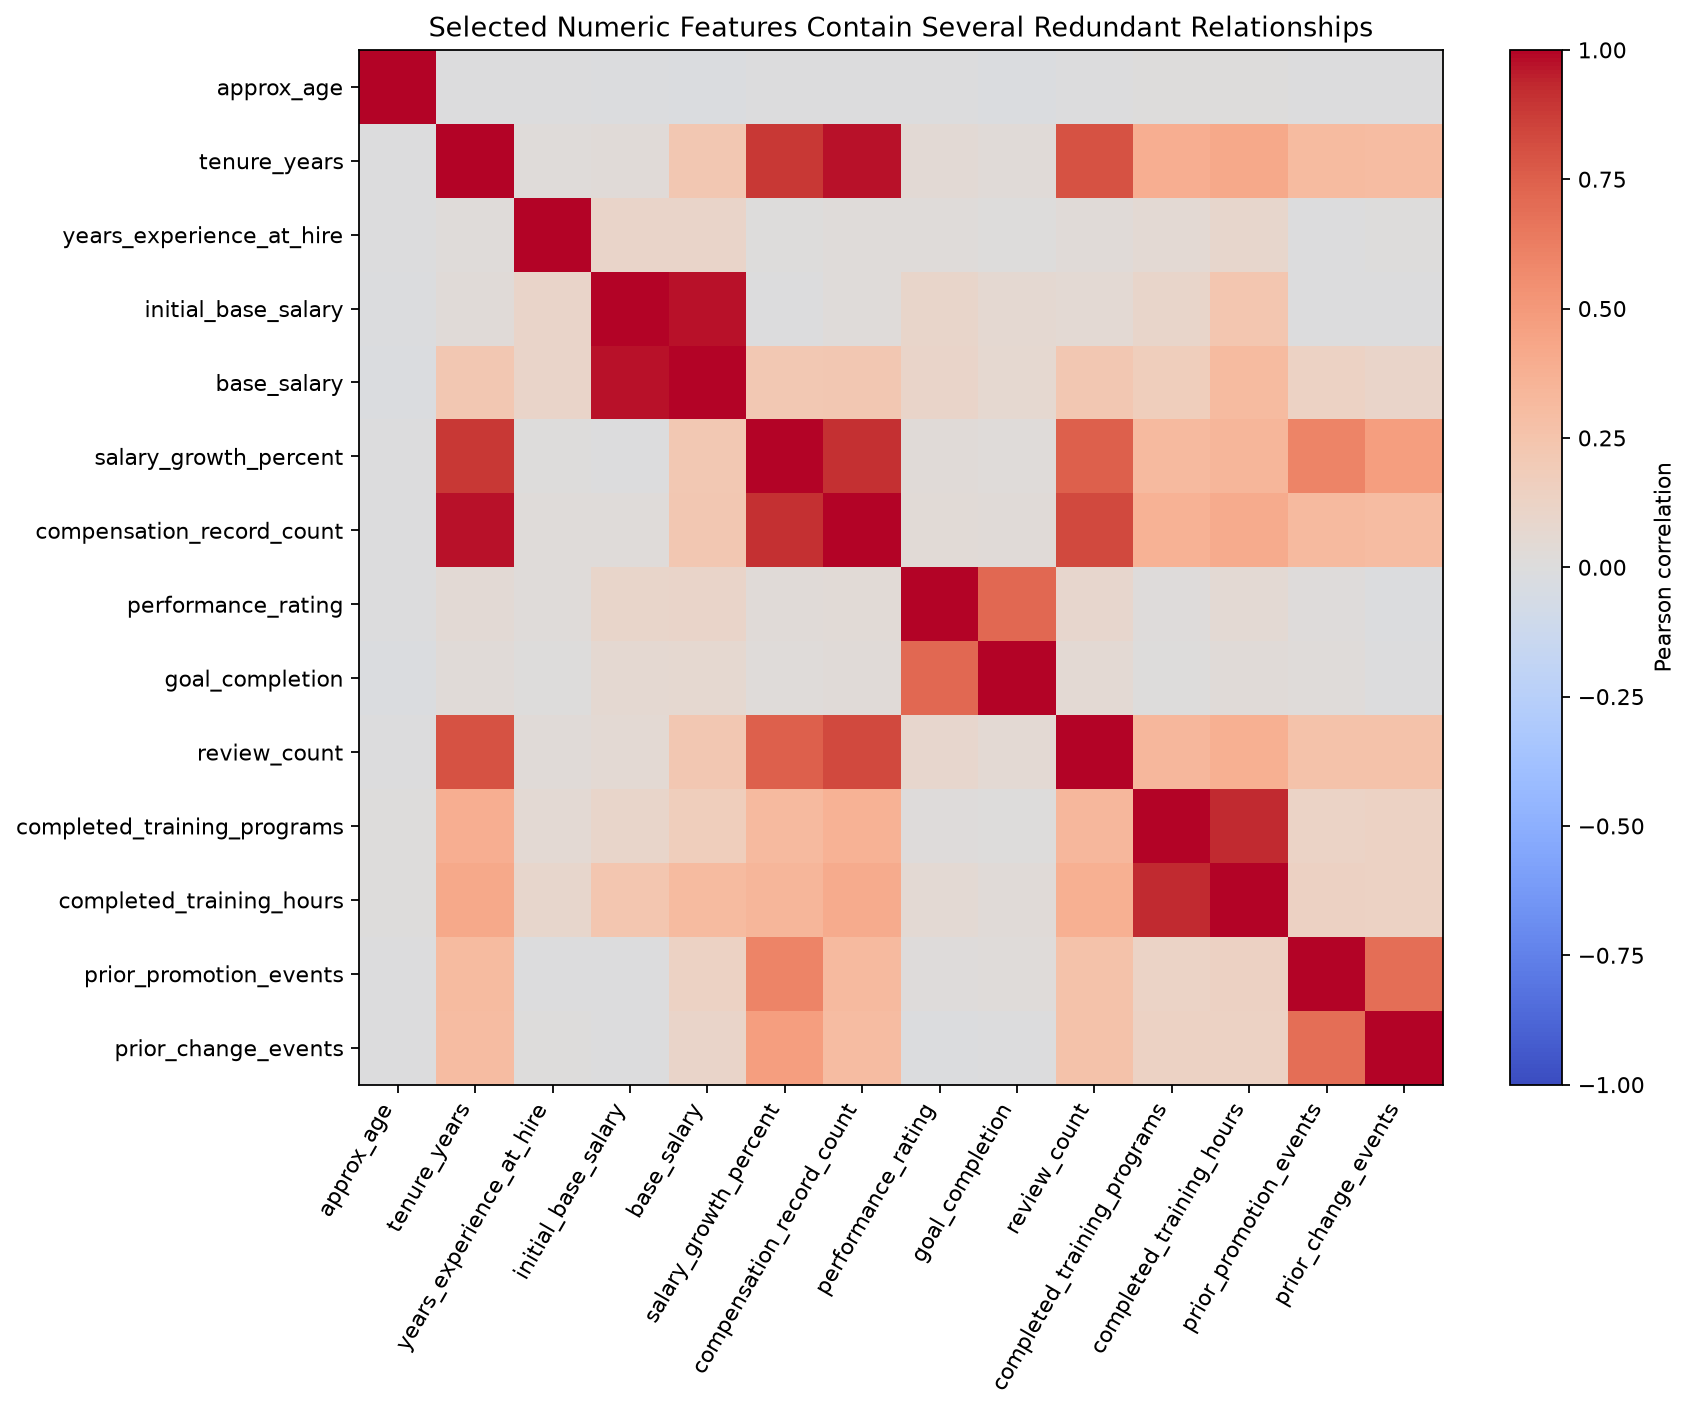

In [3]:
figure_directory = EDA_DIR / "figures"

for figure_path in sorted(
    figure_directory.glob("*.png")
):
    title = (
        figure_path.stem
        .split("_", maxsplit=1)[-1]
        .replace("_", " ")
        .title()
    )

    display(Markdown(f"## {title}"))
    display(
        Image(
            filename=str(figure_path)
        )
    )

## Main Findings

### Population and imbalance

The modeling population contains 7,386 employees observed on June 30, 2025. Of these, 627 terminate during the following 12 months, producing an attrition prevalence of 8.49%.

Because 91.51% of records belong to the negative class, accuracy should not be treated as the primary evaluation metric.

### Department and job-family patterns

Manufacturing has the highest department-level 12-month attrition rate at 10.46%, followed by Customer Support at 10.03%. These patterns are consistent with the hard-coded probability increases identified in the generator audit.

Department and job family are also strongly redundant. Their corrected Cramér's V is 0.84.

### Observation-time relationships

Tenure, compensation-record count, salary growth, and review count have the largest standardized differences between outcome groups. These features are also strongly correlated with one another.

This is consistent with longer-tenured employees having more opportunities to accumulate reviews, compensation changes, training, and internal events.

### Missingness

Missing review variables indicate that an employee had no qualifying review before the snapshot. Missing `days_since_last_change_event` usually indicates that no prior change event existed.

These values should be represented explicitly during modeling instead of being treated as unexplained data-quality failures.

### Redundancy

Several feature pairs are effectively duplicates:

- Promotion compensation count and prior promotion events
- Days since compensation change and days since review
- Initial and current base salary
- Current and average performance rating
- Completed training count and completed training hours

These relationships require correction or careful feature selection before interpreting model coefficients.

### Interpretation limit

This EDA characterizes the Version 1 synthetic data. It does not establish causal workforce relationships or evidence about Tesla or another real employer.